# Real Data Performance

This notebook compares the performance of the EM approach to LOOCV approach using real-world datasets.

## Preview Experiment

In [1]:
import numpy as np
import pandas as pd

from fastridge import RidgeEM, RidgeLOOCV
from experiments import Experiment
from problems import EmpiricalDataProblem, PolynomialExpansion, onehot_non_numeric
from neurips2023 import NEURIPS2023_TRAIN_SIZES

problems = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=onehot_non_numeric, zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',                                          zero_variance_filter=True),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength',                                  zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',   'target',                                                         zero_variance_filter=True),
    EmpiricalDataProblem('eye',        'y',                                                              zero_variance_filter=True),
    EmpiricalDataProblem('forest',     'area',                          x_transforms=onehot_non_numeric, zero_variance_filter=True),
    EmpiricalDataProblem('student',    ('G1', 'G2', 'G3'),              x_transforms=onehot_non_numeric, zero_variance_filter=True),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',                                           zero_variance_filter=True),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=onehot_non_numeric, zero_variance_filter=True),
]

estimators = {
    'EM':     RidgeEM(),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
    'CV_glm': RidgeLOOCV(alphas=100),
}

exp = Experiment(
    problems, list(estimators.values()),
    reps=10, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems],
    seed=123,
    est_names=list(estimators.keys())).run(ignore_cache=True)
print()

  0%|          | 0/9 [00:00<?, ?it/s]

abalone:   0%|          | 0/30 [00:00<?, ?it/s]

abalone  —  30 computed, 0 retrieved  (0.2s)


airfoil:   0%|          | 0/30 [00:00<?, ?it/s]

airfoil  —  30 computed, 0 retrieved  (0.1s)


...

student  —  30 computed, 0 retrieved  (0.3s)


yacht:   0%|          | 0/30 [00:00<?, ?it/s]

yacht  —  30 computed, 0 retrieved  (0.1s)


automobile:   0%|          | 0/30 [00:00<?, ?it/s]

automobile  —  30 computed, 0 retrieved  (0.2s)



In [2]:
def stat_mean(exp, stat_name, est_name, problem_idx):
    j = exp.est_names.index(est_name)
    return np.nanmean(getattr(exp, stat_name + '_')[:, problem_idx, 0, j])

rows = []
for i, problem in enumerate(exp.problems):
    em_time = stat_mean(exp, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp, 'prediction_r2', est, i) for est in exp.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp.ns[i, 0])
    row['n:p']      = int(exp.ns[i, 0]) / stat_mean(exp, 'number_of_features', 'EM', i)
    rows.append(row)
pd.DataFrame(rows).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.52,0.52,0.52,8.59,9.0,2923,324.78
1,airfoil,scaled-sound-pressure,0.50,0.50,0.50,7.31,5.0,1052,210.40
2,concrete,Concrete compressive strength,0.61,0.61,0.61,6.56,8.0,721,90.12
6,student,"G1, G2, G3",0.28,0.28,0.28,4.16,39.0,454,11.64
5,forest,area,-0.03,-0.03,-0.10,0.85,26.2,361,13.78
3,diabetes,target,0.49,0.49,0.49,5.45,10.0,309,30.90
7,yacht,Residuary_resistance,0.62,0.62,0.62,4.55,6.0,215,35.83
8,automobile,price,0.86,0.84,0.84,2.96,49.7,111,2.23
4,eye,y,0.53,0.26,0.48,0.84,200.0,84,0.42


In [3]:
problems_d2 = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                         zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength', x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',   'target',                        x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('eye',        'y',                             x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('forest',     'area',                          x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                         zero_variance_filter=True),
    EmpiricalDataProblem('student',    ('G1', 'G2', 'G3'),              x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                         zero_variance_filter=True),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',          x_transforms=(PolynomialExpansion(2),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                         zero_variance_filter=True),
]

In [4]:
exp_d2 = Experiment(
    problems_d2, list(estimators.values()),
    reps=10, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_d2],
    seed=123,
    est_names=list(estimators.keys())).run(ignore_cache=True)
print()

  0%|          | 0/9 [00:00<?, ?it/s]

abalone:   0%|          | 0/30 [00:00<?, ?it/s]

abalone  —  30 computed, 0 retrieved  (0.5s)


airfoil:   0%|          | 0/30 [00:00<?, ?it/s]

airfoil  —  30 computed, 0 retrieved  (0.2s)


...

student  —  30 computed, 0 retrieved  (1.3s)


yacht:   0%|          | 0/30 [00:00<?, ?it/s]

yacht  —  30 computed, 0 retrieved  (0.1s)


automobile:   0%|          | 0/30 [00:00<?, ?it/s]

automobile  —  30 computed, 0 retrieved  (0.5s)



In [5]:
rows_d2 = []
for i, problem in enumerate(exp_d2.problems):
    em_time = stat_mean(exp_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_d2, 'prediction_r2', est, i) for est in exp_d2.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d2, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d2.ns[i, 0])
    row['n:p']      = int(exp_d2.ns[i, 0]) / stat_mean(exp_d2, 'number_of_features', 'EM', i)
    rows_d2.append(row)
pd.DataFrame(rows_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.42,0.41,0.41,3.83,53.00,2923,55.15
1,airfoil,scaled-sound-pressure,0.62,0.62,0.62,3.35,20.00,1052,52.60
2,concrete,Concrete compressive strength,0.77,0.78,0.78,4.09,44.00,721,16.39
6,student,"G1, G2, G3",0.28,-2.78,0.24,1.27,798.40,454,0.57
5,forest,area,-0.03,-0.03,-0.33,0.60,291.78,361,1.24
3,diabetes,target,0.47,0.47,0.47,2.83,65.00,309,4.75
7,yacht,Residuary_resistance,0.91,0.91,0.91,4.36,27.00,215,7.96
8,automobile,price,0.87,-1408.17,0.84,0.93,999.40,111,0.11
4,eye,y,0.23,0.23,0.24,1.11,20300.00,84,0.00


In [6]:
problems_d3 = [
    EmpiricalDataProblem('abalone',    'Rings',                         x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                         zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',    'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('concrete',   'Concrete compressive strength', x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',   'target',                        x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    # EmpiricalDataProblem('eye',        'y'),  # excluded in paper for d=3
    EmpiricalDataProblem('forest',     'area',                          x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                         zero_variance_filter=True),
    EmpiricalDataProblem('student',    ('G1', 'G2', 'G3'),              x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                         zero_variance_filter=True),
    EmpiricalDataProblem('yacht',      'Residuary_resistance',          x_transforms=(PolynomialExpansion(3),),                                 zero_variance_filter=True),
    EmpiricalDataProblem('automobile', 'price', nan_policy='drop_rows', x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                         zero_variance_filter=True),
]

In [7]:
exp_d3 = Experiment(
    problems_d3, list(estimators.values()),
    reps=10, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_d3],
    seed=123,
    est_names=list(estimators.keys())).run(ignore_cache=True)
print()

  0%|          | 0/8 [00:00<?, ?it/s]

abalone:   0%|          | 0/30 [00:00<?, ?it/s]

abalone  —  30 computed, 0 retrieved  (1.6s)


airfoil:   0%|          | 0/30 [00:00<?, ?it/s]

airfoil  —  30 computed, 0 retrieved  (0.3s)


...

student  —  30 computed, 0 retrieved  (7.6s)


yacht:   0%|          | 0/30 [00:00<?, ?it/s]

yacht  —  30 computed, 0 retrieved  (0.2s)


automobile:   0%|          | 0/30 [00:00<?, ?it/s]

automobile  —  30 computed, 0 retrieved  (3.7s)



In [8]:
rows_d3 = []
for i, problem in enumerate(exp_d3.problems):
    em_time = stat_mean(exp_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_d3, 'prediction_r2', est, i) for est in exp_d3.est_names})
    row['Speed-Up'] = cv_time / em_time
    row['p']        = stat_mean(exp_d3, 'number_of_features', 'EM', i)
    row['n_train']  = int(exp_d3.ns[i, 0])
    row['n:p']      = int(exp_d3.ns[i, 0]) / stat_mean(exp_d3, 'number_of_features', 'EM', i)
    rows_d3.append(row)
pd.DataFrame(rows_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed-Up,p,n_train,n:p
0,abalone,Rings,0.30,0.09,0.15,2.80,209.0,2923,13.99
1,airfoil,scaled-sound-pressure,0.72,0.73,0.73,3.62,55.0,1052,19.13
2,concrete,Concrete compressive strength,0.86,0.85,0.86,2.55,164.0,721,4.40
5,student,"G1, G2, G3",0.26,-0.56,-0.54,0.74,10532.5,454,0.04
4,forest,area,-0.03,-201.23,-0.81,0.34,1938.6,361,0.19
3,diabetes,target,0.41,0.41,0.41,1.66,285.0,309,1.08
6,yacht,Residuary_resistance,0.99,0.99,0.97,2.35,83.0,215,2.59
7,automobile,price,0.77,-1669.34,0.78,0.75,11998.1,111,0.01


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from plotting import scatter_clipped, grid_with_colourbar

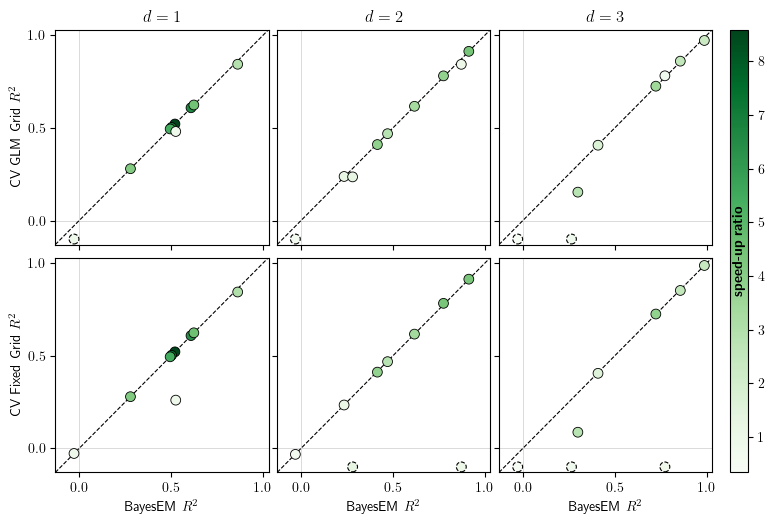

In [10]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp, exp_d2, exp_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp, exp_d2, exp_d3]):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


## Full Experiment: Small and Moderately-sized Datasets

This experiment corresponds to Figure 3 of the appendix.

In [ ]:
problems_full = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=onehot_non_numeric,                         zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',                                                    zero_variance_filter=True),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=onehot_non_numeric,          zero_variance_filter=True),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=('car_name',), nan_policy='drop_rows',                                                      zero_variance_filter=True),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=('state', 'fold', 'communityname'),
                         nan_policy='drop_cols',                                                                          zero_variance_filter=True),
    EmpiricalDataProblem('ribo',             'y',                                                                         zero_variance_filter=True),
    EmpiricalDataProblem('eye',              'y',                                                                         zero_variance_filter=True),
    EmpiricalDataProblem('boston',           'medv',                                                                      zero_variance_filter=True),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength',                                             zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',         'target',                                                                    zero_variance_filter=True),
    EmpiricalDataProblem('facebook',         ('comment', 'like', 'share'),
                         drop=('Total Interactions',),
                         nan_policy='drop_rows',                    x_transforms=onehot_non_numeric,                                   zero_variance_filter=True),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=onehot_non_numeric,                         zero_variance_filter=True),
    EmpiricalDataProblem('naval_propulsion', ('GT_compressor_decay', 'GT_turbine_decay'),                                zero_variance_filter=True),
    EmpiricalDataProblem('parkinsons',       ('motor_UPDRS', 'total_UPDRS'),                                             zero_variance_filter=True),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',                                               zero_variance_filter=True),
    EmpiricalDataProblem('student',          ('G1', 'G2', 'G3'),                               x_transforms=onehot_non_numeric,        zero_variance_filter=True),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',                                                      zero_variance_filter=True),
]

estimators_full = {
    'EM':     RidgeEM(),
    'CV_fix': RidgeLOOCV(alphas=np.logspace(-10, 10, 100, endpoint=True, base=10)),
    'CV_glm': RidgeLOOCV(alphas=100),
}

exp_full = Experiment(
    problems_full, list(estimators_full.values()),
    reps=100, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_full],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

In [12]:
rows_full = []
for i, problem in enumerate(exp_full.problems):
    em_time = stat_mean(exp_full, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full, 'prediction_r2', est, i) for est in exp_full.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full.ns[i, 0])
    row['n:p']            = int(exp_full.ns[i, 0]) / stat_mean(exp_full, 'number_of_features', 'EM', i)
    rows_full.append(row)
pd.DataFrame(rows_full).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
12,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",0.88,0.88,0.87,9.70,15.00,8353,556.87
13,parkinsons,"motor_UPDRS, total_UPDRS",0.16,0.16,0.16,6.90,19.00,4112,216.42
0,abalone,Rings,0.53,0.53,0.53,22.96,9.00,2923,324.78
4,crime,ViolentCrimesPerPop,0.66,0.66,0.66,4.69,99.00,1395,14.09
1,airfoil,scaled-sound-pressure,0.51,0.51,0.51,34.68,5.00,1052,210.40
8,concrete,Concrete compressive strength,0.61,0.61,0.61,30.52,8.00,721,90.12
15,student,"G1, G2, G3",0.27,0.27,0.27,4.37,39.00,454,11.64
11,forest,area,-0.03,-0.04,-0.13,3.71,26.55,361,13.60
7,boston,medv,0.70,0.70,0.70,27.98,13.00,354,27.23
10,facebook,"comment, like, share",0.30,0.28,0.15,5.74,17.00,349,20.53


In [ ]:
problems_full_d2 = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                          zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),              zero_variance_filter=True),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=('car_name',), nan_policy='drop_rows', x_transforms=(PolynomialExpansion(2),),                                           zero_variance_filter=True),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=('state', 'fold', 'communityname'),
                         nan_policy='drop_cols',                    x_transforms=(PolynomialExpansion(2),),                                            zero_variance_filter=True),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d=2
    EmpiricalDataProblem('eye',              'y',                             x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('boston',           'medv',                          x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength', x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',         'target',                        x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('facebook',         ('comment', 'like', 'share'),
                         drop=('Total Interactions',),
                         nan_policy='drop_rows',                    x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                                    zero_variance_filter=True),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                           zero_variance_filter=True),
    EmpiricalDataProblem('naval_propulsion', ('GT_compressor_decay', 'GT_turbine_decay'), x_transforms=(PolynomialExpansion(2),),                      zero_variance_filter=True),
    EmpiricalDataProblem('parkinsons',       ('motor_UPDRS', 'total_UPDRS'),              x_transforms=(PolynomialExpansion(2),),                      zero_variance_filter=True),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',    x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('student',          ('G1', 'G2', 'G3'),              x_transforms=onehot_non_numeric + (PolynomialExpansion(2),),                          zero_variance_filter=True),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',          x_transforms=(PolynomialExpansion(2),),                                  zero_variance_filter=True),
]

In [14]:
exp_full_d2 = Experiment(
    problems_full_d2, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_full_d2],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

abalone ..........................................................................................
airfoil ..................

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


........................................................................
automobile ....

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


......................................................................................
autompg ...............

...

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


.........................................................................................
parkinsons ..........................................................................................
real_estate ..........................................................................................
student .

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


.........................................................................................
yacht ..........................................................................................



/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


In [15]:
rows_full_d2 = []
for i, problem in enumerate(exp_full_d2.problems):
    em_time = stat_mean(exp_full_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full_d2, 'prediction_r2', est, i) for est in exp_full_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d2.ns[i, 0])
    row['n:p']            = int(exp_full_d2.ns[i, 0]) / stat_mean(exp_full_d2, 'number_of_features', 'EM', i)
    rows_full_d2.append(row)
pd.DataFrame(rows_full_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
11,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",1.00,1.00,0.99,3.18,149.00,8353,56.06
12,parkinsons,"motor_UPDRS, total_UPDRS",0.24,0.23,0.24,2.89,209.00,4112,19.67
0,abalone,Rings,0.49,0.48,0.48,6.63,53.00,2923,55.15
4,crime,ViolentCrimesPerPop,0.67,-0.84,0.66,1.28,5049.00,1395,0.28
1,airfoil,scaled-sound-pressure,0.63,0.63,0.63,15.63,20.00,1052,52.60
7,concrete,Concrete compressive strength,0.78,0.78,0.78,8.72,44.00,721,16.39
14,student,"G1, G2, G3",0.28,-2.79,0.27,1.24,798.30,454,0.57
10,forest,area,-0.04,-0.04,-0.41,0.88,295.76,361,1.22
6,boston,medv,0.83,0.82,0.82,4.21,104.00,354,3.40
9,facebook,"comment, like, share",-5.12,-79.05,-0.60,1.79,166.97,349,2.09


In [ ]:
problems_full_d3 = [
    EmpiricalDataProblem('abalone',          'Rings',                         x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                          zero_variance_filter=True),
    EmpiricalDataProblem('airfoil',          'scaled-sound-pressure',         x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('automobile',       'price',               nan_policy='drop_rows', x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),              zero_variance_filter=True),
    EmpiricalDataProblem('autompg',          'mpg',
                         drop=('car_name',), nan_policy='drop_rows', x_transforms=(PolynomialExpansion(3),),                                           zero_variance_filter=True),
    EmpiricalDataProblem('crime',            'ViolentCrimesPerPop',
                         drop=('state', 'fold', 'communityname'),
                         nan_policy='drop_cols',                    x_transforms=(PolynomialExpansion(3),),                                            zero_variance_filter=True),
    # EmpiricalDataProblem('ribo',             'y'),  # memory exhaustion at d>=2
    # EmpiricalDataProblem('eye',              'y'),  # excluded in paper for d=3
    EmpiricalDataProblem('boston',           'medv',                          x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('concrete',         'Concrete compressive strength', x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('diabetes',         'target',                        x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('facebook',         ('comment', 'like', 'share'),
                         drop=('Total Interactions',),
                         nan_policy='drop_rows',                    x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                                    zero_variance_filter=True),
    EmpiricalDataProblem('forest',           'area',                          x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                           zero_variance_filter=True),
    EmpiricalDataProblem('naval_propulsion', ('GT_compressor_decay', 'GT_turbine_decay'), x_transforms=(PolynomialExpansion(3),),                      zero_variance_filter=True),
    EmpiricalDataProblem('parkinsons',       ('motor_UPDRS', 'total_UPDRS'),              x_transforms=(PolynomialExpansion(3),),                      zero_variance_filter=True),
    EmpiricalDataProblem('real_estate',      'Y house price of unit area',    x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
    EmpiricalDataProblem('student',          ('G1', 'G2', 'G3'),              x_transforms=onehot_non_numeric + (PolynomialExpansion(3),),                          zero_variance_filter=True),
    EmpiricalDataProblem('yacht',            'Residuary_resistance',          x_transforms=(PolynomialExpansion(3),),                                  zero_variance_filter=True),
]

In [17]:
exp_full_d3 = Experiment(
    problems_full_d3, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_full_d3],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

abalone ..........................................................................................
airfoil .........

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


.................................................................................
automobile 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................
autompg ..........

...

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................
parkinsons ..........................................................................................
real_estate ..........................................................................................
student 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................
yacht ..........................................................................................



/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


In [18]:
rows_full_d3 = []
for i, problem in enumerate(exp_full_d3.problems):
    em_time = stat_mean(exp_full_d3, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_full_d3, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_full_d3, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': ', '.join(problem.target) if isinstance(problem.target, tuple) else problem.target}
    row.update({est: stat_mean(exp_full_d3, 'prediction_r2', est, i) for est in exp_full_d3.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_full_d3.ns[i, 0])
    row['n:p']            = int(exp_full_d3.ns[i, 0]) / stat_mean(exp_full_d3, 'number_of_features', 'EM', i)
    rows_full_d3.append(row)
pd.DataFrame(rows_full_d3).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
10,naval_propulsion,"GT_compressor_decay, GT_turbine_decay",1.00,1.00,1.00,2.61,963.00,8353,8.67
11,parkinsons,"motor_UPDRS, total_UPDRS",-1.37,-0.15,-0.21,1.88,1539.00,4112,2.67
0,abalone,Rings,0.47,0.37,0.39,3.31,209.00,2923,13.99
4,crime,ViolentCrimesPerPop,0.65,-0.20,0.57,1.09,25076.00,1395,0.06
1,airfoil,scaled-sound-pressure,0.73,0.73,0.73,6.71,55.00,1052,19.13
6,concrete,Concrete compressive strength,0.85,0.85,0.85,3.35,164.00,721,4.40
13,student,"G1, G2, G3",0.26,-0.55,-0.47,0.74,10529.53,454,0.04
9,forest,area,-0.04,-782.80,-1.12,0.37,1967.43,361,0.18
5,boston,medv,0.81,-160.26,0.81,2.04,559.00,354,0.63
8,facebook,"comment, like, share",-16.80,-144191.55,-1.01,1.01,1086.47,349,0.32


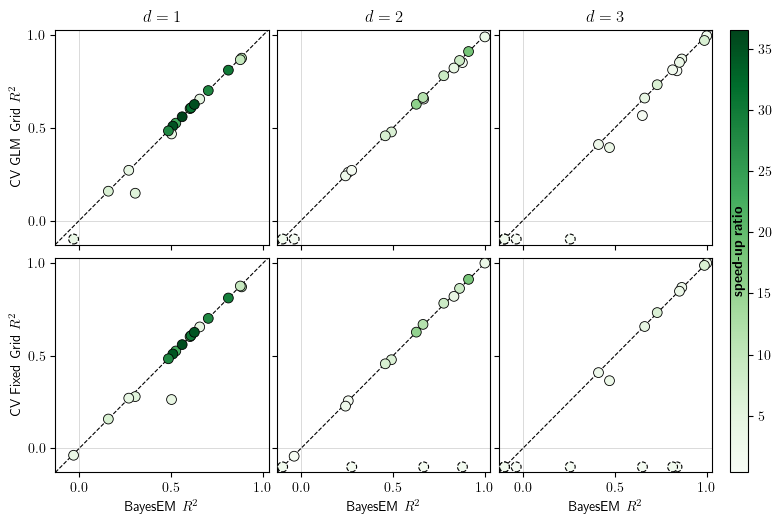

In [19]:
su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for e in [exp_full, exp_full_d2, exp_full_d3] for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, e in enumerate([exp_full, exp_full_d2, exp_full_d3]):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0),
                        np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0),
                        np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                        / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0),
                        norm, plt.cm.Greens, ax=axes[row, col])


In [21]:
problems_large = [
    EmpiricalDataProblem('twitter',   'V78',       zero_variance_filter=True),
    EmpiricalDataProblem('tomshw',    'V97',       zero_variance_filter=True),
    EmpiricalDataProblem('blog',      'V281',      zero_variance_filter=True),
    EmpiricalDataProblem('ct_slices', 'reference', zero_variance_filter=True),
]

In [22]:
exp_large = Experiment(
    problems_large, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_large],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

twitter ..........................................................................................
tomshw 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................
blog 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................
ct_slices 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................



/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


In [24]:
rows_large = []
for i, problem in enumerate(exp_large.problems):
    em_time = stat_mean(exp_large, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large, 'prediction_r2', est, i) for est in exp_large.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large.ns[i, 0])
    row['n:p']            = int(exp_large.ns[i, 0]) / stat_mean(exp_large, 'number_of_features', 'EM', i)
    rows_large.append(row)
pd.DataFrame(rows_large).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.93,0.93,0.93,5.53,77.00,408275,5302.27
3,ct_slices,reference,0.86,0.86,0.86,4.06,379.53,37450,98.67
2,blog,V281,0.36,0.36,0.36,4.37,276.00,36677,132.89
1,tomshw,V97,0.96,0.96,0.96,4.25,96.00,19725,205.47


In [25]:
problems_large_d2 = [
    EmpiricalDataProblem('twitter',   'V78',       x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
    EmpiricalDataProblem('tomshw',    'V97',       x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
    EmpiricalDataProblem('blog',      'V281',      x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
    EmpiricalDataProblem('ct_slices', 'reference', x_transforms=(PolynomialExpansion(2),), zero_variance_filter=True),
]

In [26]:
exp_large_d2 = Experiment(
    problems_large_d2, list(estimators_full.values()),
    reps=30, ns=[[NEURIPS2023_TRAIN_SIZES[p.dataset]] for p in problems_large_d2],
    seed=123,
    est_names=list(estimators_full.keys())).run()
print()

twitter ..........................................................................................
tomshw 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................
blog 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................
ct_slices 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


..........................................................................................



/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:407: UserWarning: FittingTime: only one computation stored; reliability unknown. Re-run with force_recompute=True to improve estimate.
  warnings.warn(msg)


In [27]:
rows_large_d2 = []
for i, problem in enumerate(exp_large_d2.problems):
    em_time = stat_mean(exp_large_d2, 'fitting_time', 'EM', i)
    cv_time = (stat_mean(exp_large_d2, 'fitting_time', 'CV_glm', i)
               + stat_mean(exp_large_d2, 'fitting_time', 'CV_fix', i)) / 2
    row = {'dataset': problem.dataset, 'target': problem.target}
    row.update({est: stat_mean(exp_large_d2, 'prediction_r2', est, i) for est in exp_large_d2.est_names})
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    row['n_train']        = int(exp_large_d2.ns[i, 0])
    row['n:p']            = int(exp_large_d2.ns[i, 0]) / stat_mean(exp_large_d2, 'number_of_features', 'EM', i)
    rows_large_d2.append(row)
pd.DataFrame(rows_large_d2).sort_values('n_train', ascending=False).round(2)

,dataset,target,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,0.91,0.91,0.91,5.42,86.00,408275,4747.38
3,ct_slices,reference,0.92,0.92,0.92,3.05,929.43,37450,40.29
2,blog,V281,-0.00,0.10,0.01,2.96,886.67,36677,41.37
1,tomshw,V97,0.92,0.96,0.96,2.08,1775.00,19725,11.11


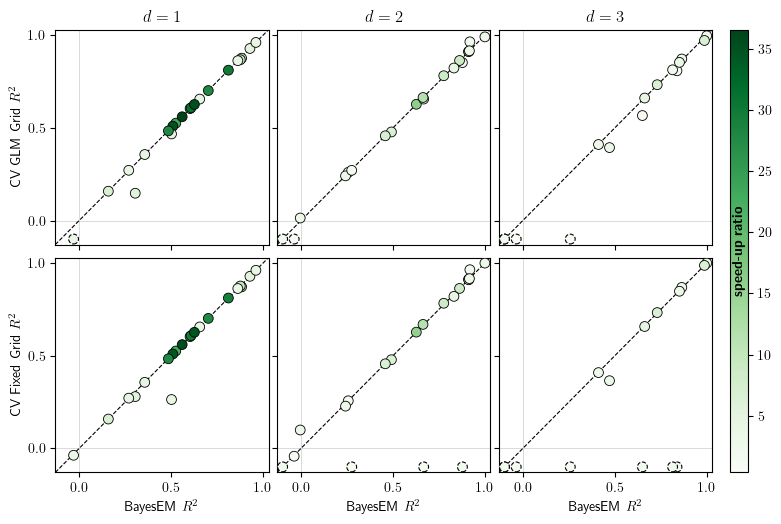

In [28]:
col_exps = [[exp_full, exp_large], [exp_full_d2, exp_large_d2], [exp_full_d3]]

su_all = [np.nanmean(e.fitting_time_[:, i, 0, cv]) / np.nanmean(e.fitting_time_[:, i, 0, 0])
          for exps in col_exps for e in exps for cv in [1, 2] for i in range(len(e.problems))]
norm = mcolors.Normalize(vmin=min(su_all), vmax=max(su_all))

fig, axes = grid_with_colourbar(2, 3, norm, plt.cm.Greens,
                                y_labels=['CV GLM Grid $R^2$', 'CV Fixed Grid $R^2$'],
                                col_titles=['$d=1$', '$d=2$', '$d=3$'],
                                x_labels='BayesEM $R^2$', cbar_label=r'\textbf{speed-up ratio}')


for col, exps in enumerate(col_exps):
    for row, cv in enumerate([2, 1]):
        scatter_clipped(
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, 0], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.prediction_r2_[:, :, 0, cv], axis=0) for e in exps]),
            np.concatenate([np.nanmean(e.fitting_time_[:, :, 0, cv], axis=0)
                            / np.nanmean(e.fitting_time_[:, :, 0, 0], axis=0) for e in exps]),
            norm, plt.cm.Greens, ax=axes[row, col])

fig.savefig('../output/realdata_r2_by_degree.pdf', bbox_inches='tight')
